# Proyek Analisis Data: [Brazilian E-Commerce Public Dataset by Olist]
- **Nama:** [Faqihuddin Al-Ghiffary]
- **Email:** [f4qihuddin@gmail.com]
- **ID Dicoding:** [faqihuddin_ag]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apakah ada hubungan antara waktu pengiriman dengan rating pelanggan?
- **Pertanyaan 2:** Apa saja 10 kategori produk-produk teratas yang paling disukai dan tidak disukai oleh pelanggan?
- **Pertanyaan 3:** Bagaimana tren pendapatan perusahaan dalam 1 tahun terakhir?
- **Pertanyaan 4:** Dari negara bagian dan kota Brazil mana saja pelanggan olist paling banyak berasal?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Menghubungkan Google Colab dengan Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Memuat Dataset

In [3]:
customer_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/olist_customers_dataset.csv')
order_items_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/olist_order_items_dataset.csv')
order_payments_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/olist_orders_dataset.csv')
products_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/olist_products_dataset.csv')
product_category_name_df = pd.read_csv('/content/drive/MyDrive/Machine Learning Datasets/Dataset E-commerce Brazil: Olist/archive (12)/product_category_name_translation.csv')

**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Mengidentifikasi Masalah pada Dataset Seperti missing value, tipe data tidak valid, dan lain-lain

In [4]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
customer_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [6]:
customer_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [7]:
print("Jumlah duplikasi: ", customer_df.duplicated().sum())

Jumlah duplikasi:  0


In [8]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [9]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [10]:
order_items_df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [11]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [12]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [13]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [14]:
order_payments_df.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [15]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [16]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [17]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [18]:
order_reviews_df.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [19]:
print('Jumlah duplikasi: ', order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [20]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [21]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [22]:
orders_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [23]:
print('Jumlah duplikasi', orders_df.duplicated().sum())

Jumlah duplikasi 0


In [24]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [25]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [26]:
products_df.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [27]:
products_df.duplicated().sum()

np.int64(0)

In [28]:
product_category_name_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [29]:
product_category_name_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [30]:
product_category_name_df.describe(include='all')

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [31]:
product_category_name_df.duplicated().sum()

np.int64(0)

**Steps to Take:**
- Melihat informasi dari setiap dataset (nilai null dan tipe data).
- Memeriksa jumlah missing value untuk setiap kolom pada setiap dataset.
- Melihat statistika deskriptif untuk setiap dataset (nilai mean, median, modus, dll)
- Memeriksa apakah terdapat duplikasi data pada setiap dataset

**Insight:** (Opsional)

dataset order_items_df:
- shipping limit date bertipe objek

dataset order_reviews_df:
- banyak nilai null pada kolom review_comment_title dan review_comment_message
- kolom review_creation_date dan review_answer_timestamp bertipe objek

dataset orders_df:
- kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date berisi nilai null
- kolom order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date bertipe objek

dataset products_df:
- semua kolom memiliki nilai null kecuali product_id

### Cleaning Data

#### Mengubah kolom waktu bertipe object menjadi datetime serta membersihkan missing value

In [32]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

In [33]:
order_reviews_df.drop(columns=['review_comment_title', 'review_comment_message'], inplace=True)

In [34]:
order_reviews_df['review_creation_date'] = pd.to_datetime(order_reviews_df['review_creation_date'])
order_reviews_df['review_answer_timestamp'] = pd.to_datetime(order_reviews_df['review_answer_timestamp'])

In [35]:
orders_df.dropna(inplace=True)

In [36]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [37]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

In [38]:
products_df.dropna(inplace=True)

**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

#### Melihat pengaruh waktu pengiriman terhadap review score pelanggan

In [39]:
orders_reviews_merged_df = pd.merge(
    left=order_reviews_df,
    right=orders_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
orders_reviews_merged_df.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-02-28 12:48:39,2018-03-02 19:08:15,2018-03-09 23:17:20,2018-03-14 00:00:00
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-03 10:33:41,2018-02-06 16:18:28,2018-02-16 17:28:48,2018-03-09 00:00:00
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-09 17:55:19,2017-04-10 14:24:47,2017-04-20 09:08:35,2017-05-10 00:00:00
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-15 19:36:14,2018-02-28 16:33:35,2018-03-09 00:00:00


In [40]:
orders_reviews_merged_df['delivery_time (days)'] = (orders_reviews_merged_df['order_delivered_customer_date'] - orders_reviews_merged_df['order_purchase_timestamp']).dt.days
orders_reviews_merged_df.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time (days)
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00,6.0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-02-28 12:48:39,2018-03-02 19:08:15,2018-03-09 23:17:20,2018-03-14 00:00:00,9.0
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-03 10:33:41,2018-02-06 16:18:28,2018-02-16 17:28:48,2018-03-09 00:00:00,13.0
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-09 17:55:19,2017-04-10 14:24:47,2017-04-20 09:08:35,2017-05-10 00:00:00,10.0
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-15 19:36:14,2018-02-28 16:33:35,2018-03-09 00:00:00,18.0


In [41]:
orders_reviews_relation = orders_reviews_merged_df.groupby(by="review_score").agg({
       "delivery_time (days)": 'mean'
}).reset_index().round(2)

orders_reviews_relation.head()

,review_score,delivery_time (days)
0,1,20.85
1,2,16.19
2,3,13.80
3,4,11.85
4,5,10.22


#### Melihat peringkat 10 teratas kategori produk yang paling disukai pelanggan dan 10 terbawah yang paling tidak disukai

In [42]:
orders_items_reviews_df = pd.merge(
    left=orders_reviews_merged_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

products_reviews_df = pd.merge(
    left=orders_items_reviews_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

products_reviews_df.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,...,185.00,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,...,185.00,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-02-28 12:48:39,2018-03-02 19:08:15,...,79.79,8.30,informatica_acessorios,47.0,493.0,1.0,245.0,19.0,14.0,14.0
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-03 10:33:41,2018-02-06 16:18:28,...,149.00,45.12,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-09 17:55:19,2017-04-10 14:24:47,...,179.99,42.85,ferramentas_jardim,33.0,2188.0,2.0,7650.0,20.0,20.0,20.0


In [43]:
product_reviews_top10 = products_reviews_df.groupby(by="product_category_name").review_score.mean().round(2).sort_values(ascending=False).reset_index().head(10)
product_reviews_top10.head(10)

,product_category_name,review_score
0,cds_dvds_musicais,4.64
1,fashion_roupa_infanto_juvenil,4.50
2,livros_interesse_geral,4.45
3,construcao_ferramentas_ferramentas,4.44
4,flores,4.42
5,livros_importados,4.40
6,livros_tecnicos,4.37
7,malas_acessorios,4.32
8,alimentos_bebidas,4.32
9,portateis_casa_forno_e_cafe,4.30


In [44]:
products_reviews_bottom10 = products_reviews_df.groupby(by="product_category_name").review_score.mean().round(2).sort_values(ascending=True).reset_index().head(10)
products_reviews_bottom10.head(10)

,product_category_name,review_score
0,seguros_e_servicos,2.50
1,fraldas_higiene,3.26
2,portateis_cozinha_e_preparadores_de_alimentos,3.27
3,pc_gamer,3.33
4,moveis_escritorio,3.49
5,casa_conforto_2,3.63
6,fashion_roupa_masculina,3.64
7,telefonia_fixa,3.68
8,artigos_de_festas,3.77
9,fashion_roupa_feminina,3.78


#### Melihat tren pendapatan perusahaan selama 1 tahun terakhir

In [45]:
orders_payments_merged_df = pd.merge(
    left=orders_df,
    right=order_payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

orders_payments_merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12


In [55]:
monthly_orders_df = orders_payments_merged_df.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "payment_value": "sum"
})
monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')
monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_id": "order_count",
    "payment_value": "revenue"
}, inplace=True)
last_year_order = monthly_orders_df.sort_values(by='order_purchase_timestamp', ascending=False).head(12)
last_year_order

/tmp/ipykernel_2203/1514081795.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = orders_payments_merged_df.resample(rule='M', on='order_purchase_timestamp').agg({


,order_purchase_timestamp,order_count,revenue
23,2018-08,6351,985414.28
22,2018-07,6156,1027383.10
21,2018-06,6096,1011561.35
20,2018-05,6749,1128836.69
19,2018-04,6798,1132933.95
18,2018-03,7003,1120678.00
17,2018-02,6556,966554.97
16,2018-01,7069,1078606.86
15,2017-12,5513,843199.17
14,2017-11,7288,1153393.22


#### Melihat Asal Negara dan Kota dari Pelanggan Olist

In [60]:
top10_customer_states = customer_df.groupby(by='customer_state').customer_unique_id.nunique().sort_values(ascending=False).reset_index().head(10)
top10_customer_states.rename(columns={'customer_unique_id': 'customer count'}, inplace=True)
top10_customer_states

,customer_state,customer count
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


In [61]:
top10_customer_cities = customer_df.groupby(by='customer_city').customer_unique_id.nunique().sort_values(ascending=False).reset_index().head(10)
top10_customer_cities.rename(columns={'customer_unique_id': 'customer count'}, inplace=True)
top10_customer_cities

,customer_city,customer count
0,sao paulo,14984
1,rio de janeiro,6620
2,belo horizonte,2672
3,brasilia,2069
4,curitiba,1465
5,campinas,1398
6,porto alegre,1326
7,salvador,1209
8,guarulhos,1153
9,sao bernardo do campo,908


**Insight:** (Opsional)
- Semakin lama waktu pengiriman maka akan semakin rendah review score dan sebaliknya. Berdasarkan data ini, perusahaan harus mencari tahu apa penyebab waktu pengiriman yang lambat dan bagaimana cara mengefisiensikan waktu pengiriman.

- Terdapat produk-produk dengan rating rata-rata yang tinggi tetapi terdapat produk dengan rating rata-rata yang rendah. Berdasarkan hasil analisis ini, perusahaan dapat mencari tahu apa saja penyebab dari tinggi atau rendahnya rating suatu produk.

- Pendapatan perusahaan selama 1 tahun terakhir berfluktuasi tetapi dari maret 2018 - juli 2018 pendapatan cenderung stabil. Berdasarkan analisis ini, perusahaan dapat mencari tahu apa penyebab penjualan menurun pada bulan-bulan tertentu dan meningkat pada bulan-bulan tertentu.

- Terdapat negara-negara bagian dengan jumlah pelanggan yang sangat banyak seperti di Saulo Paulo, tetapi ada juga negara bagian dengan jumlah pelanggan yang sedikit

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apakah ada hubungan antara waktu pengiriman dengan rating pelanggan?

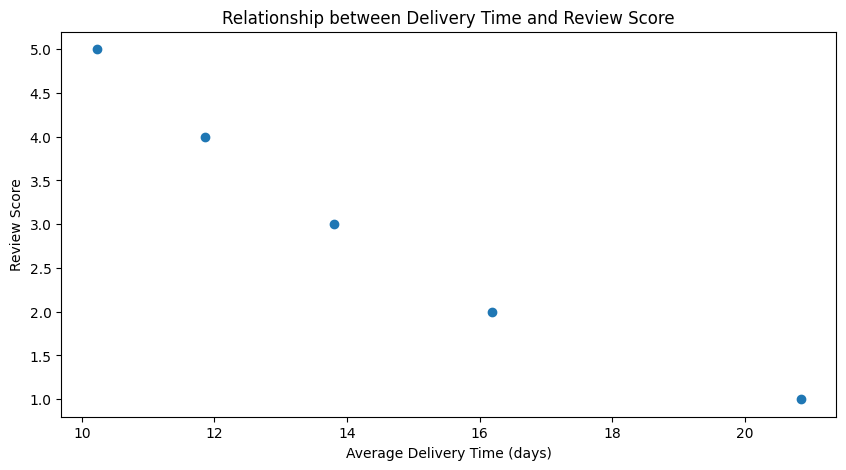

In [49]:
plt.figure(figsize=(10, 5))
plt.scatter(x=orders_reviews_relation['delivery_time (days)'], y=orders_reviews_relation['review_score'])
plt.xlabel('Average Delivery Time (days)')
plt.ylabel('Review Score')
plt.title('Relationship between Delivery Time and Review Score')
plt.show()

### Pertanyaan 2: Apa saja 10 kategori produk-produk teratas yang paling disukai dan tidak disukai oleh pelanggan?

/tmp/ipykernel_2203/2236432557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="review_score", y="product_category_name", data=product_reviews_top10, palette=colors, ax=ax[0])
/tmp/ipykernel_2203/2236432557.py:5: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="review_score", y="product_category_name", data=product_reviews_top10, palette=colors, ax=ax[0])
/tmp/ipykernel_2203/2236432557.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="review_score", y="product_category_name", data=products_reviews_bottom10.head(10), palette=colors, ax=ax[1])
/tmp/ipykernel_2203/2236432557.py:11: User

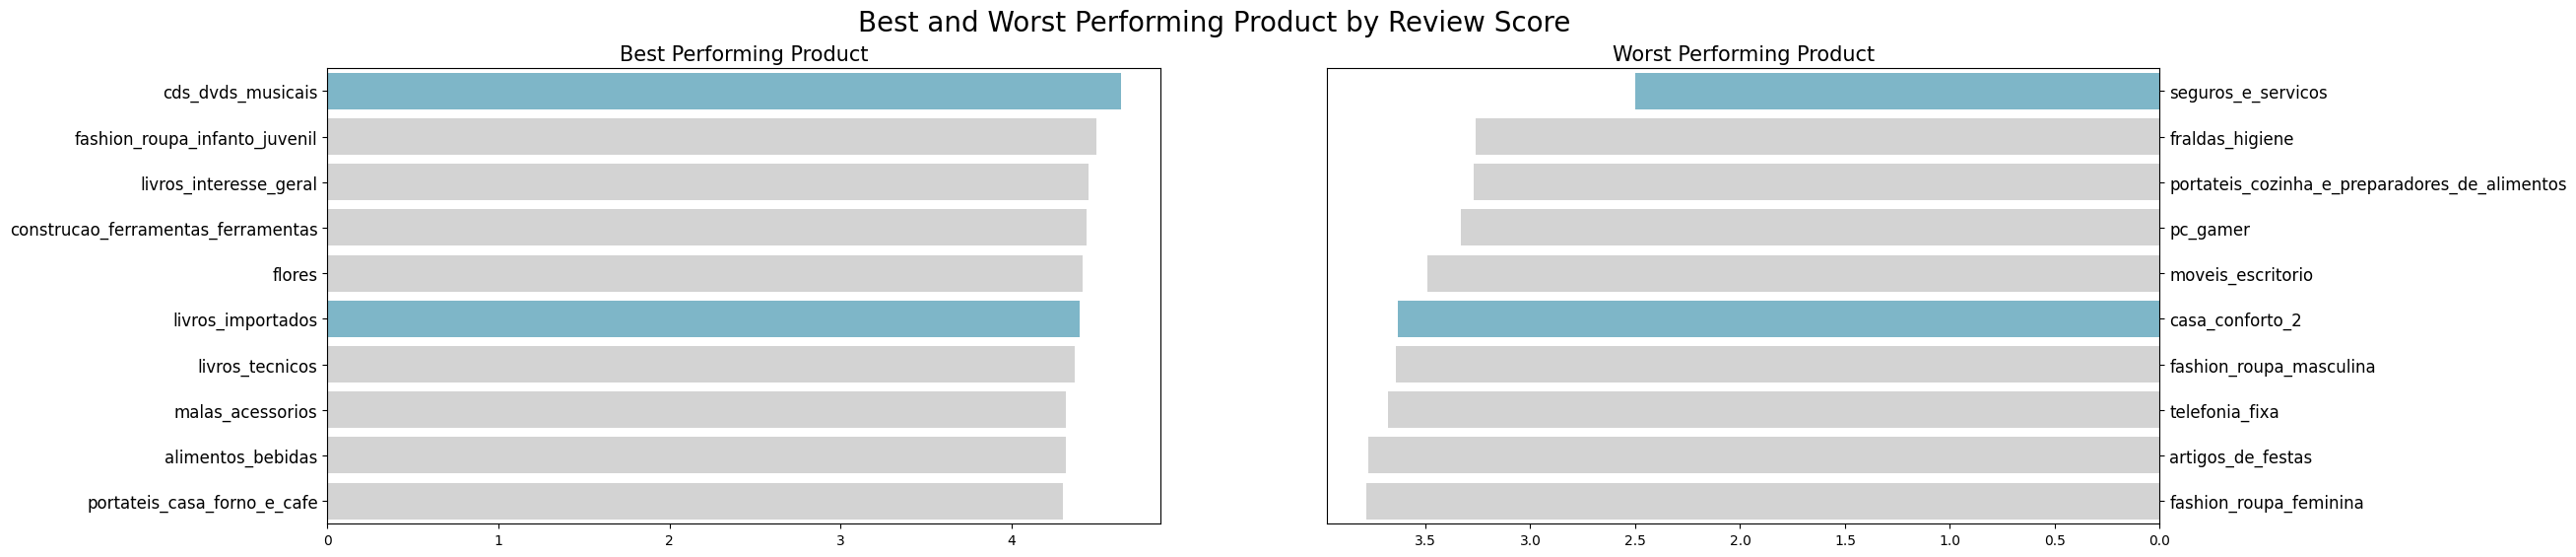

In [51]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="review_score", y="product_category_name", data=product_reviews_top10, palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="review_score", y="product_category_name", data=products_reviews_bottom10.head(10), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Product by Review Score", fontsize=20)
plt.show()

### Pertanyaan 3: Bagaimana tren pendapatan perusahaan dalam 1 tahun terakhir?

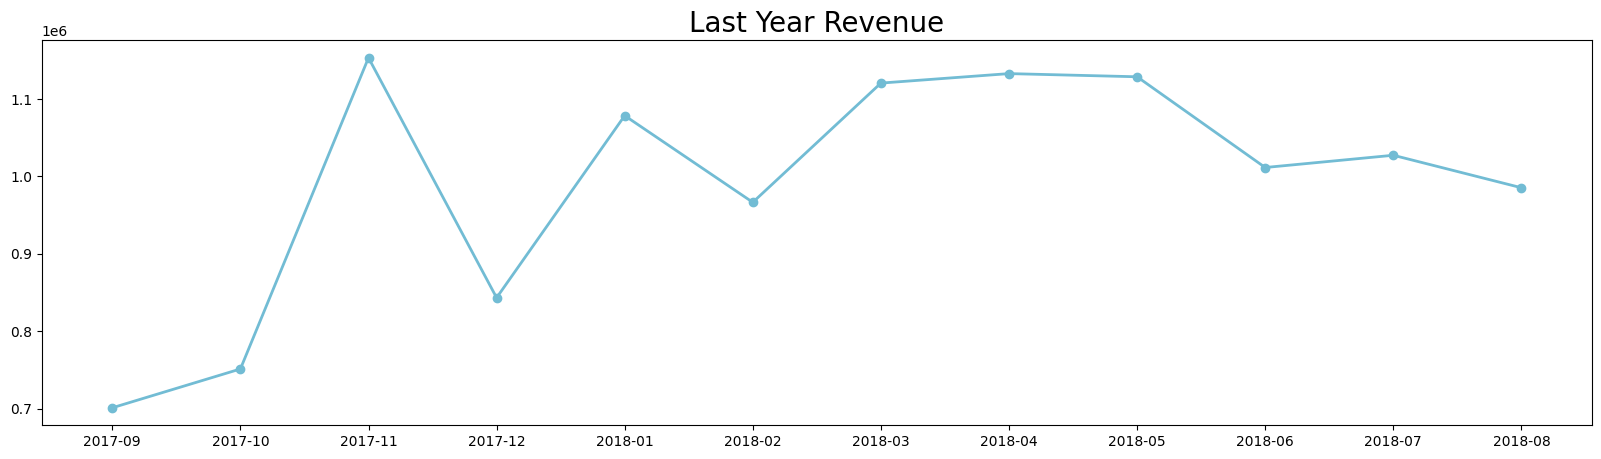

In [52]:
plt.figure(figsize=(20, 5))
plt.plot(
    last_year_order.sort_values(ascending=True, by='order_purchase_timestamp')["order_purchase_timestamp"],
    last_year_order.sort_values(ascending=True, by='order_purchase_timestamp')["revenue"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Last Year Revenue", loc="center", fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Pertanyaan 4: Dari negara bagian dan kota Brazil mana saja pelanggan olist paling banyak berasal?

/tmp/ipykernel_2203/3780956223.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer count", y="customer_state", data=top10_customer_states, palette=colors)
/tmp/ipykernel_2203/3780956223.py:5: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="customer count", y="customer_state", data=top10_customer_states, palette=colors)


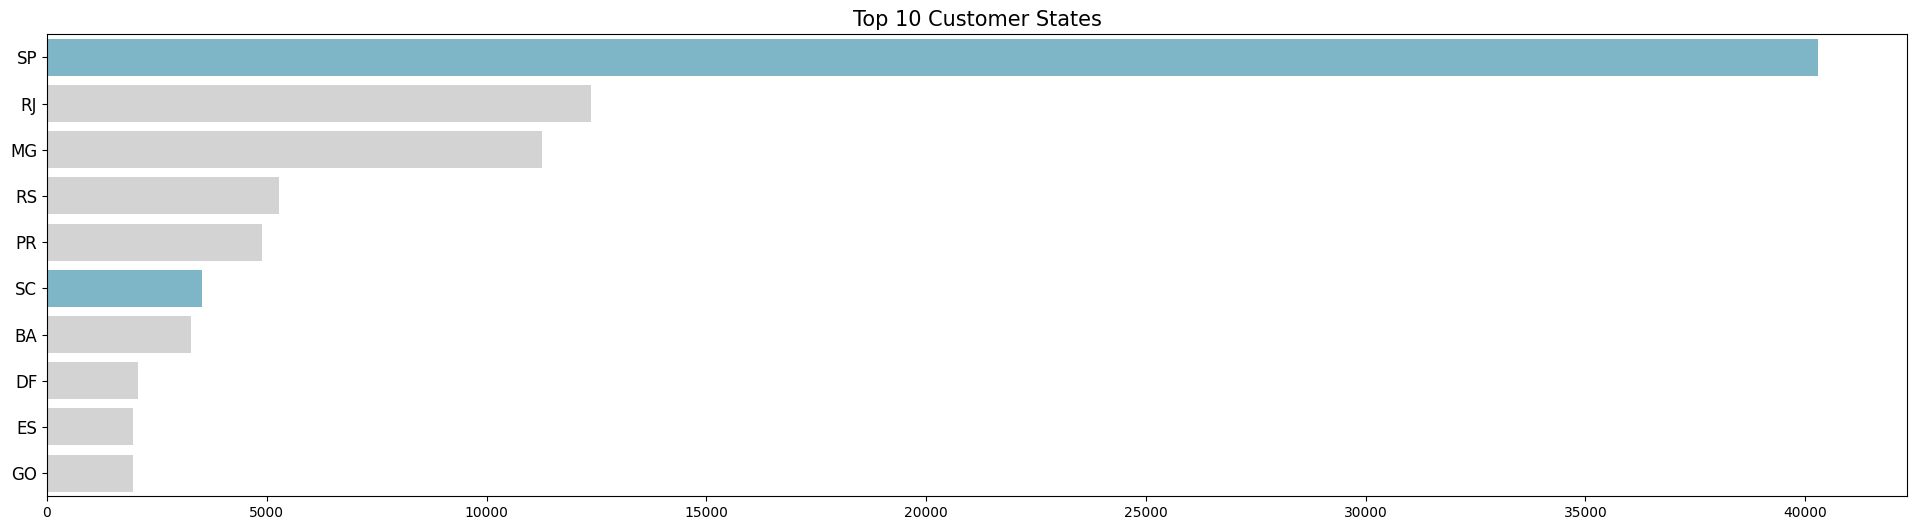

In [67]:
plt.figure(figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="customer count", y="customer_state", data=top10_customer_states, palette=colors)
plt.ylabel(None)
plt.xlabel(None)
plt.title("Top 10 Customer States", loc="center", fontsize=15)
plt.tick_params(axis ='y', labelsize=12)
plt.show()

/tmp/ipykernel_2203/2146946997.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer count", y="customer_city", data=top10_customer_cities, palette=colors)
/tmp/ipykernel_2203/2146946997.py:5: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="customer count", y="customer_city", data=top10_customer_cities, palette=colors)


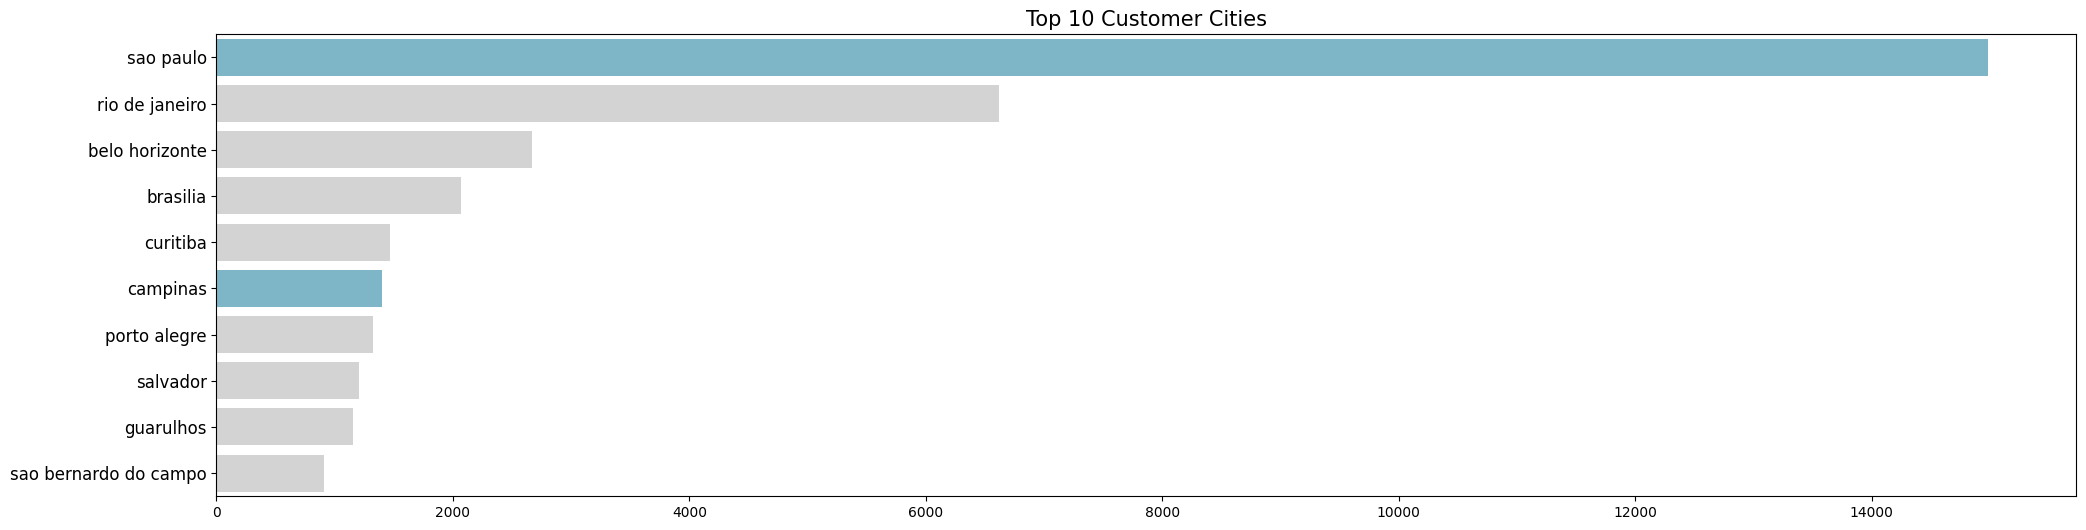

In [72]:
plt.figure(figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="customer count", y="customer_city", data=top10_customer_cities, palette=colors)
plt.ylabel(None)
plt.xlabel(None)
plt.title("Top 10 Customer Cities", loc="center", fontsize=15)
plt.tick_params(axis ='y', labelsize=12)
plt.show()

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Waktu pengiriman sangat memengaruhi kepuasan pelanggan, berdasarkan data sekarang masih terdapat banyak pelanggan yang tidak puas sehingga memberikan review score rendah karena waktu pengiriman yang lambat.

- **Conclusion pertanyaan 2:** Terdapat produk dengan rating yang tinggi dan juga rendah, penyebabnya bisa banyak hal, oleh karena itu perusahaan dapat mencari tahu penyebabnya lebih lanjut.

- **Conclusion pertanyaan 3:** Pendapatan 1 tahun terakhir sangat berfluktuasi mesikipun sempat cenderung stabil untuk beberapa bulan.

- **Conclusion pertanyaan 4:** Terdapat negara bagian dan kota brazil yang ramai dengan pelanggan Olist tetapi ada juga beberapa negara bagian dan kota yang masih minim pelanggan.

**Rekomendasi Action Item:**
- Optimalisasi proses pengiriman barang agar waktu pengiriman lebih efisien.
- Analisis lebih lanjut penyebab rendahnya dan tingginya review score suatu produk.
- Analisis lebih lanjut apa penyebab turunnya pembelian pada bulan-bulan tertentu misalnya seperti mengadakan sebuah event promosi.
- Merancang strategi marketing khususnya pada negara bagian dan kota yang masih minim pelanggan misalnya dengan mengadakan suatu event.

## Upload Dataframe Baru ke CSV

In [ ]:
orders_reviews_merged_df.to_csv('orders_reviews_merged_df.csv', index=False)
products_reviews_df.to_csv('products_reviews_df.csv', index=False)
orders_payments_merged_df.to_csv('orders_payments_merged_df.csv', index=False)